# Laboratorio 6. Analítica de Redes Sociales

Para este laboratorio vamos a analizar la estructura de participación de usuarios en una muestra de videos de Youtube, estudiando su relación entre los autores, videos, canales y temas. 

En esta sección se evalúan los primeros 4 ejercicios. 

1. Carga, comprensión e integración de los datos.
2. Calidad, limpieza y preprocesamiento.
3. Análisis exploratorio.
4. Construcción de la red bipartita autor-video.

## 0. Preparación del entorno

Se importan las bibliotecas necesarias para manipulación de datos,
visualización y construcción de redes.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import networkx as nx
import textwrap

import re
from collections import Counter

import nltk 
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

stopwords_es = set(stopwords.words("spanish"))

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

# Ejercicio 1 Carga, comprensión e integración

- 1.1 cargar archivos
- 1.2 identificar unidades, IDs y variables
- 1.3 explicar las relaciones
- 1.4 unir los datasets

In [2]:
videos = pd.read_csv("../data/youtube_videos.csv")
comments = pd.read_csv("../data/youtube_comments.csv")

In [3]:
videos.head()

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana en Guatemala,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante este fin d...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno del Niño"", ""Guatemala"", ""Lluvias en Guatemala"", ""...",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante este fin d...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA DE DETERIORO INSTITUCIONAL,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y jefe del Mi...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y jefe del Mi...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Huachicol #Gu...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado Guatemala"", ""huachicol frontera sur"", ""Pemex notic...",#México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Huachicol #G...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder
3,-O4Pa7qS9WQ,"Viaje completo Ciudad de Guatemala al IRTRA de Retalhuleu, menos tráfico, Diesel a Q42.59",Guate Maya Trip,UCSQM9AVr3rr7_GF8RH5KFGw,guatemala trafico,topic,youtube_guatemala_lab.csv,/@GuateMayaTripGT,hace 5 meses,383 vistas,NaN,https://www.youtube.com/watch?v=-O4Pa7qS9WQ,"[""guatemala trafico""]",[],NaN,383,2026-03-27T22:00:00-07:00,2026-03-27T22:00:00-07:00,Nonprofits & Activism,/@GuateMayaTripGT
4,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_plus.csv,/@Noti7Guatemala,hace 2 semanas,"6,692 vistas",La rápida acción policial frustró el plan de los sujetos que usaron minifaldas para huir.,https://www.youtube.com/watch?v=06mFNPU0aB8,"[""guatemala noticias""]","[""Actualidad"", ""Asaltantes disfrazados"", ""Capturados Escuintla"", ""Guatemala"", ""Noti7"", ""Noticias...",La rápida acción policial frustró el plan de los sujetos que usaron minifaldas para huir.,6692,2026-08-13T22:00:12-07:00,2026-08-13T22:00:12-07:00,News & Politics,/@Noti7Guatemala


In [4]:
comments.head()

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_comments.csv,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guatemala_plus_comments.csv,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila",@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_comments.csv,/@iamjimalesssa,hace 1 año,4,0,False,NaN
3,j43HgwYFKfk,Ugw0xgUc2ISpBr5_T654AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@gonzalo6075,UCkbsS_3D-pvg1iHOld9uvIg,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la sombra.,@quorumgt/videos,channel,quorum_complete_comments.csv | youtube_guatemala_plus_comments.csv,/@gonzalo6075,hace 1 año,,0,False,NaN
4,OkXlHx0hx-8,Ugw1ZzA21njWhaqQQTh4AaABAg,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,@luisroldan7374,UCOLHH4ZpMxPYF-Q6e6wvn5A,eso es para que salga de USA por su propio pie \nque se auto deporten,guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guatemala_plus_comments.csv,/@luisroldan7374,hace 1 día,2,1,False,NaN


In [5]:
# dimensiones 
print("Videos:", videos.shape)
print("Comentarios:", comments.shape)

Videos: (293, 20)
Comentarios: (406, 17)


In [6]:
videos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   video_id             293 non-null    object
 1   title                293 non-null    object
 2   channel_name         293 non-null    object
 3   channel_id           293 non-null    object
 4   source_query         293 non-null    object
 5   source_group         293 non-null    object
 6   dataset_sources      293 non-null    object
 7   channel_handle       293 non-null    object
 8   published_time       280 non-null    object
 9   view_count_text      280 non-null    object
 10  description_snippet  268 non-null    object
 11  video_url            293 non-null    object
 12  query_hits           293 non-null    object
 13  keywords             293 non-null    object
 14  description          267 non-null    object
 15  view_count           293 non-null    int64 
 16  publish_

In [7]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   video_id           406 non-null    object 
 1   comment_id         406 non-null    object 
 2   video_title        406 non-null    object 
 3   channel_name       406 non-null    object 
 4   channel_id         406 non-null    object 
 5   author_name        406 non-null    object 
 6   author_channel_id  406 non-null    object 
 7   text               406 non-null    object 
 8   source_query       406 non-null    object 
 9   source_group       406 non-null    object 
 10  dataset_sources    406 non-null    object 
 11  author_handle      406 non-null    object 
 12  published_text     406 non-null    object 
 13  like_count_text    406 non-null    object 
 14  reply_count        406 non-null    int64  
 15  is_pinned          406 non-null    bool   
 16  viewer_rating      0 non-n

In [8]:
videos.columns.tolist()

['video_id',
 'title',
 'channel_name',
 'channel_id',
 'source_query',
 'source_group',
 'dataset_sources',
 'channel_handle',
 'published_time',
 'view_count_text',
 'description_snippet',
 'video_url',
 'query_hits',
 'keywords',
 'description',
 'view_count',
 'publish_date',
 'upload_date',
 'category',
 'owner_handle']

In [9]:
comments.columns.tolist()

['video_id',
 'comment_id',
 'video_title',
 'channel_name',
 'channel_id',
 'author_name',
 'author_channel_id',
 'text',
 'source_query',
 'source_group',
 'dataset_sources',
 'author_handle',
 'published_text',
 'like_count_text',
 'reply_count',
 'is_pinned',
 'viewer_rating']

### 1.2 Unidad de observación e identificadores

#### Dataset `youtube_videos.csv`

- **Unidad de observación:** un video de YouTube.
- **Llave primaria:** `video_id`.
- **Identificador del canal:** `channel_id`.
- **Variables relevantes:** `title`, `channel_name`, `channel_id`,
  `category`, `source_query`, `view_count`, `publish_date`,
  `keywords` y `description`.

#### Dataset `youtube_comments.csv`

- **Unidad de observación:** un comentario principal publicado en un video.
- **Llave primaria:** `comment_id`.
- **Llave foránea:** `video_id`.
- **Identificador del autor:** `author_channel_id`.
- **Variables relevantes:** `text`, `author_name`, `author_channel_id`,
  `channel_id`, `reply_count`, `like_count_text`, `source_query`
  y `published_text`.

Los nombres visibles como `channel_name`, `author_name` o los handles
se utilizarán principalmente para visualización. Los identificadores
estables serán utilizados para construir y relacionar los datos.

### 1.3 Relación entre las entidades

La estructura de los datos puede interpretarse de la siguiente manera:

**Canal → Video → Comentario ← Autor**

- Un **canal** puede publicar varios videos.
- Cada **video** pertenece a un canal.
- Un **autor** puede publicar comentarios en uno o varios videos.
- Cada **comentario** pertenece a un video y tiene un autor.
- Cada video posee una **categoría** de YouTube.
- La **consulta de búsqueda (`source_query`)** indica la consulta utilizada
  durante la recolección para encontrar el contenido y no necesariamente
  representa el tema definitivo del video.


In [10]:
# revisar ID duplicados 
print("video_id duplicados en videos:",
      videos["video_id"].duplicated().sum())

print("comment_id duplicados en comentarios:",
      comments["comment_id"].duplicated().sum())

video_id duplicados en videos: 0
comment_id duplicados en comentarios: 0


In [11]:
data = comments.merge(
    videos,
    on="video_id",
    how="left",
    suffixes=("_comment", "_video"),
    indicator=True
)
asociados = (data["_merge"] == "both").sum()
no_asociados = (data["_merge"] == "left_only").sum()

print("Comentarios asociados:", asociados)
print("Comentarios no asociados:", no_asociados)
print("Porcentaje asociado:", asociados / len(data) * 100)

Comentarios asociados: 406
Comentarios no asociados: 0
Porcentaje asociado: 100.0


Podemos notar que los datasets fueron integrados utilizando video_id como llave. 
Podemos notar que todos los comentarios están asociados a un video. Esto nos permite comprobar la integridad referencial entre ambos conjuntos además de que no hay duplicados en los identificadores de cada conjunto.

# Ejercicio 2 - Calidad, limpieza y preprocesamiento

- dimensiones
- tipos
- faltantes
- duplicados
- constantes
- outliers
- consistencia
- variables problemáticas
- normalización
- conversión numérica
- texto original
- texto limpio
- medir el efecto de la limpieza.

In [12]:
# dimensiones 
print("Videos")
print("Filas:", videos.shape[0])
print("Columnas:", videos.shape[1])

print("\nComentarios")
print("Filas:", comments.shape[0])
print("Columnas:", comments.shape[1])

Videos
Filas: 293
Columnas: 20

Comentarios
Filas: 406
Columnas: 17


In [13]:
# tipos 
videos.dtypes 

video_id               object
title                  object
channel_name           object
channel_id             object
source_query           object
source_group           object
dataset_sources        object
channel_handle         object
published_time         object
view_count_text        object
description_snippet    object
video_url              object
query_hits             object
keywords               object
description            object
view_count              int64
publish_date           object
upload_date            object
category               object
owner_handle           object
dtype: object

In [14]:
comments.dtypes

video_id              object
comment_id            object
video_title           object
channel_name          object
channel_id            object
author_name           object
author_channel_id     object
text                  object
source_query          object
source_group          object
dataset_sources       object
author_handle         object
published_text        object
like_count_text       object
reply_count            int64
is_pinned               bool
viewer_rating        float64
dtype: object

In [15]:
# faltantes 
def reporte_faltantes(df):
    faltantes = df.isna().sum()
    porcentaje = (faltantes / len(df)) * 100
    reporte = pd.DataFrame({"faltantes": faltantes, "porcentaje": porcentaje})
    return pd.DataFrame(reporte).sort_values(by="porcentaje", ascending=False)

reporte_faltantes(videos)

,faltantes,porcentaje
description,26,8.873720
description_snippet,25,8.532423
published_time,13,4.436860
view_count_text,13,4.436860
channel_id,0,0.000000
channel_name,0,0.000000
title,0,0.000000
video_id,0,0.000000
channel_handle,0,0.000000
dataset_sources,0,0.000000


In [16]:
reporte_faltantes(comments)

,faltantes,porcentaje
viewer_rating,406,100.0
video_id,0,0.0
comment_id,0,0.0
channel_name,0,0.0
video_title,0,0.0
author_name,0,0.0
author_channel_id,0,0.0
text,0,0.0
channel_id,0,0.0
source_query,0,0.0


In [17]:
#duplicados 
print("video_id duplicados en videos:",
    videos.duplicated(subset=['video_id']).sum())

print("comment_id duplicados en comentarios:",
    comments.duplicated(subset=['comment_id']).sum())

video_id duplicados en videos: 0
comment_id duplicados en comentarios: 0


In [18]:
# variables constantes 
constantes_videos = [
    col for col in videos.columns 
    if videos[col].nunique(dropna=False) <= 1
]

constantes_comentarios = [
    col for col in comments.columns 
    if comments[col].nunique(dropna=False) <= 1
]

print("Variables constantes en videos:", constantes_videos)
print("Variables constantes en comentarios:", constantes_comentarios)

Variables constantes en videos: []
Variables constantes en comentarios: ['is_pinned', 'viewer_rating']


is_pinned es FALSE para todos los registros 
el viewer_rating es NULL para todos los registros

In [19]:
# Valores atípicos
videos.select_dtypes(include="number").describe()


,view_count
count,2.930000e+02
mean,6.043009e+04
std,5.157983e+05
min,2.000000e+00
25%,2.150000e+02
50%,1.175000e+03
75%,7.465000e+03
max,8.190449e+06


In [20]:
comments.select_dtypes(include="number").describe()

,reply_count,viewer_rating
count,406.000000,0.0
mean,0.125616,NaN
std,0.580748,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,0.000000,NaN
75%,0.000000,NaN
max,7.000000,NaN


In [21]:
q1 = videos["view_count"].quantile(0.25)
q3 = videos["view_count"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_views = videos[
    (videos["view_count"] < limite_inferior) |
    (videos["view_count"] > limite_superior)
]

print("Posibles outliers:", len(outliers_views))

Posibles outliers: 49


Mediante el criterio del rango intercuartílico (IQR) se identificaron 49
observaciones potencialmente atípicas en `view_count`, equivalentes
aproximadamente al 16.72 % de los videos.

Estas observaciones no se eliminan automáticamente, ya que un número
elevado de visualizaciones puede representar un video legítimamente popular
y no necesariamente un error en los datos. La distribución presenta una
fuerte asimetría hacia la derecha.

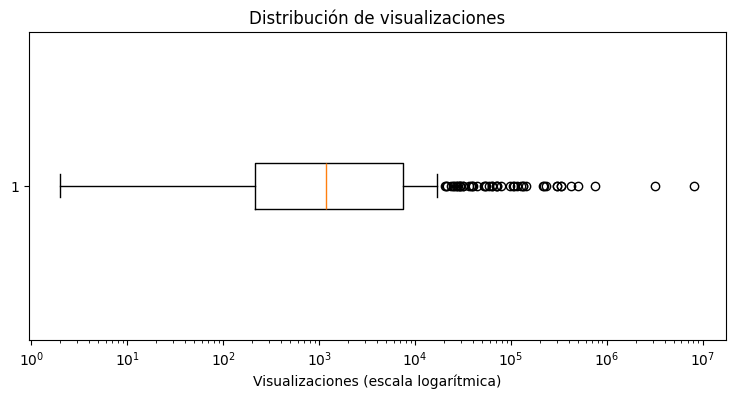

In [22]:
plt.figure(figsize=(9, 4))

plt.boxplot(
    videos["view_count"].dropna(),
    vert=False,
    showfliers=True
)

plt.xscale("log")

plt.title("Distribución de visualizaciones")
plt.xlabel("Visualizaciones (escala logarítmica)")

plt.show()

La distribución de visualizaciones presenta una fuerte asimetría, debido a
que algunos videos tienen un número de visualizaciones considerablemente
mayor al resto.

Por esta razón se utiliza una escala logarítmica, que permite visualizar
la distribución sin eliminar las observaciones extremas.

In [23]:
# consistencia ID <-> nombre 
# un mismo channel_id tiene varios channel_name?
consistencia_canal = (
    videos
    .groupby("channel_id")["channel_name"]
    .nunique()
    .sort_values(ascending=False)
)

consistencia_canal.head(10)

channel_id
UC-DpoeBbCMOMOH1-j71KPqA    1
UC-GLagjBhWAZ3IOWFgzqIAw    1
UC-YGRGi0FeIA5441bGlHOPw    1
UC-ZtFBHzgkYFh7whZkuR_Ag    1
UC-rcR68a-aLwAnszxTG4--A    1
UC1B5-Dun1FHWae_rIJdfhow    1
UC2EbdGoJZwR_WvkmB0i4rMg    1
UC6SA1dVHvAkc6yNS_t5cbGw    1
UC6XLvudi9BWjAzCR-6KAHiw    1
UC6Y7Hk0Otm2xeX1WoHOQp6Q    1
Name: channel_name, dtype: int64

In [24]:
consistencia_canal[
    consistencia_canal > 1
]

Series([], Name: channel_name, dtype: int64)

In [25]:
consistencia_autores = (
    comments
    .groupby("author_channel_id")["author_name"]
    .nunique()
    .sort_values(ascending=False)
)

consistencia_autores[
    consistencia_autores > 1
].head()

Series([], Name: author_name, dtype: int64)

### 2.2 Variables que requieren precaución

Se identificaron varias variables que requieren tratamiento especial:

- `viewer_rating`: no puede utilizarse si permanece completamente vacía.
- `is_pinned`: no aporta información si todos los registros tienen el mismo valor.
- `published_time` y `published_text`: representan tiempos relativos y no deben
  interpretarse directamente como fechas exactas.
- `channel_name` y `author_name`: pueden cambiar o repetirse, por lo que no
  deben sustituir a los identificadores.
- `source_query`: representa el procedimiento de recolección y no necesariamente
  el tema real del contenido.
- `reply_count`: únicamente indica cuántas respuestas recibió un comentario,
  pero no permite determinar quién respondió a quién.

In [26]:
# NORMALIZACION 
ids_videos = [
    "video_id",
    "channel_id"
]

ids_comments = [
    "video_id",
    "comment_id",
    "channel_id",
    "author_channel_id"
]

for col in ids_videos:
    videos[col] = videos[col].astype("string").str.strip()

for col in ids_comments:
    comments[col] = comments[col].astype("string").str.strip()

In [27]:
# nombres visibles 
columnas_texto_videos = [
    "channel_name",
    "channel_handle"
]

for col in columnas_texto_videos:
    if col in videos.columns:
        videos[col] = videos[col].astype("string").str.strip()

In [28]:
# comentarios 
columnas_texto_comments = [
    "author_name",
    "author_handle",
    "channel_name"
]

for col in columnas_texto_comments:
    if col in comments.columns:
        comments[col] = comments[col].astype("string").str.strip()

In [29]:
# conversión de conteos 
def convertir_conteo(valor):

    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip().lower()

    if texto == "":
        return np.nan

    texto = texto.replace(",", "")

    multiplicador = 1

    if texto.endswith("k"):
        multiplicador = 1_000
        texto = texto[:-1]

    elif texto.endswith("m"):
        multiplicador = 1_000_000
        texto = texto[:-1]

    try:
        return float(texto) * multiplicador

    except ValueError:
        return np.nan

In [30]:
comments["like_count"] = (
    comments["like_count_text"]
    .apply(convertir_conteo)
)

In [31]:
comments[
    ["like_count_text", "like_count"]
].head(15)

,like_count_text,like_count
0,,NaN
1,,NaN
2,4,4.0
3,,NaN
4,2,2.0
5,,NaN
6,,NaN
7,3,3.0
8,2,2.0
9,,NaN


In [32]:
# crear texto original y limpio 
comments["texto_original"] = comments["text"].copy()


In [33]:
# limpiar texto 
def limpiar_texto(texto):

    if pd.isna(texto):
        return ""

    texto = str(texto)

    # minúsculas
    texto = texto.lower()

    # eliminar URLs
    texto = re.sub(r"http\S+|www\.\S+", "", texto)

    # quitar símbolo @ pero conservar palabra
    texto = re.sub(r"@(\w+)", r"\1", texto)

    # quitar # pero conservar hashtag
    texto = re.sub(r"#(\w+)", r"\1", texto)

    # quitar puntuación
    texto = re.sub(r"[^\w\sáéíóúüñ]", " ", texto)

    # quitar números
    texto = re.sub(r"\d+", "", texto)

    # espacios múltiples
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()

In [34]:
comments["texto_limpio"] = (
    comments["texto_original"]
    .apply(limpiar_texto)
)


In [35]:
comments[
    ["texto_original", "texto_limpio"]
].head(10)


,texto_original,texto_limpio
0,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel
1,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del...",están jóvenes porque no buscan un trabajo tuvieron suerte que no hay policías que le gusta del o...
2,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila",me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales esto no es una maquila
3,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la sombra.,veremos a este mafioso de mazariegos en la cárcel y un buen tiempo en la sombra
4,eso es para que salga de USA por su propio pie \nque se auto deporten,eso es para que salga de usa por su propio pie que se auto deporten
5,Imagine if they had to walk back home.,imagine if they had to walk back home
6,buenísima investigacion :hand-purple-blue-peace::hand-purple-blue-peace::hand-purple-blue-peace:,buenísima investigacion hand purple blue peace hand purple blue peace hand purple blue peace
7,"Lleven su lonchera, sacrifiquense un poco. Y reintevren ese dinero. O están robando.",lleven su lonchera sacrifiquense un poco y reintevren ese dinero o están robando
8,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,viva guatemala
9,LADRONES !!!!,ladrones


#### Decisiones de limpieza
para la limpieza de texto se aplicaron las siguientes transformaciones:

- conversión a minúsculas;
- eliminación de URLs;
- eliminación de los símbolos # y  @ , conservando la palabra asociada;
- eliminación de puntuación;
- eliminación de números;
- normalización de espacios.

Por el momento no se aplica lematización de manera automática, ya que esta
requiere un modelo lingüístico específico para español y puede modificar
información relevante.

Los emojis se eliminan de `texto_limpio`, pero permanecen disponibles en
`texto_original`. Esto permite utilizarlos posteriormente si aportan información
para el análisis de sentimiento.

In [36]:
# STOPWORDS 
stopwords_es = {
    "de", "la", "el", "los", "las",
    "y", "o", "que", "en", "un",
    "una", "unos", "unas", "por",
    "para", "con", "del", "al",
    "se", "es", "lo", "como",
    "su", "sus", "a"
}

In [37]:
# Cuantificacion de limpieza 
duplicados_original = (
    comments["texto_original"]
    .duplicated()
    .sum()
)

vacios_original = (
    comments["texto_original"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)


In [38]:
duplicados_limpios = (
    comments["texto_limpio"]
    .duplicated()
    .sum()
)

vacios_limpios = (
    comments["texto_limpio"]
    .eq("")
    .sum()
)

In [39]:
modificados = (
    comments["texto_original"]
    .fillna("")
    .ne(comments["texto_limpio"])
    .sum()
)


In [40]:
resumen_limpieza = pd.DataFrame({
    "Métrica": [
        "Textos modificados",
        "Vacíos antes",
        "Vacíos después",
        "Duplicados antes",
        "Duplicados después"
    ],

    "Cantidad": [
        modificados,
        vacios_original,
        vacios_limpios,
        duplicados_original,
        duplicados_limpios
    ]
})

resumen_limpieza

,Métrica,Cantidad
0,Textos modificados,401
1,Vacíos antes,0
2,Vacíos después,4
3,Duplicados antes,2
4,Duplicados después,9


# Ejercicio 3 - Análisis exploratorio

conteo de videos, canales, comentarios, autores, participaciones por video, visualizaciones, respuestas, likes, categorías, consultas, hashtagas, palabras y bigramas

In [41]:
resumen_general = pd.Series({
    "Videos": videos["video_id"].nunique(),
    "Canales": videos["channel_id"].nunique(),
    "Comentarios": comments["comment_id"].nunique(),
    "Autores": comments["author_channel_id"].nunique()
})

resumen_general

Videos         293
Canales         97
Comentarios    406
Autores        332
dtype: int64

In [42]:
# VIdeos por canal 
videos_por_canal = (
    videos
    .groupby(["channel_id", "channel_name"])
    .size()
    .reset_index(name="numero_videos")
    .sort_values("numero_videos", ascending=False)
)

videos_por_canal.head(10)

,channel_id,channel_name,numero_videos
3,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,32
54,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,27
26,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,18
28,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,17
15,UC8u2nvyHewt-mjdWSj0HJmQ,Ministerio de Gobernación,14
63,UCaivrAhro2BpsJdrPe-IyRg,Diario de Centro América,11
17,UCAutgrPkiLhZxTB-Ujje1fw,CIV -Ministerio de Comunicaciones,11
52,UCW_PHqwqCCalvQGOEsVU0jw,Concejales de Oposición - Muni Guate,10
34,UCHsYnV67K3J0yJ4QeciVCww,PNCdeGuatemala,10
7,UC6SA1dVHvAkc6yNS_t5cbGw,Conred,8


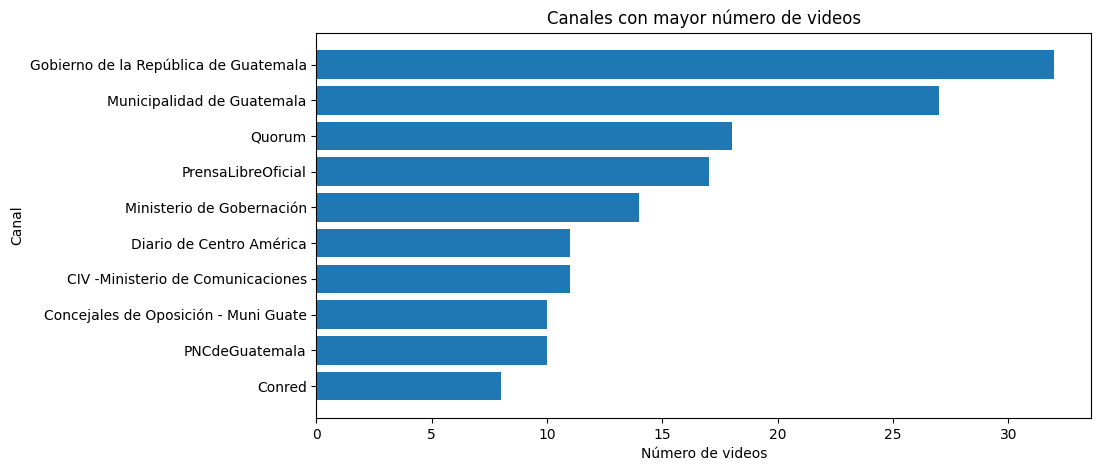

In [43]:
top = videos_por_canal.head(10)

plt.figure(figsize=(10, 5))

plt.barh(
    top["channel_name"],
    top["numero_videos"]
)

plt.gca().invert_yaxis()

plt.xlabel("Número de videos")
plt.ylabel("Canal")
plt.title("Canales con mayor número de videos")

plt.show()

In [44]:
participacion_video = (
    comments
    .groupby(["video_id", "video_title"])
    .agg(
        comentarios=("comment_id", "count"),
        autores_unicos=("author_channel_id", "nunique")
    )
    .reset_index()
    .sort_values("comentarios", ascending=False)
)

participacion_video.head(10)

,video_id,video_title,comentarios,autores_unicos
14,n8iP75gIpmw,Qué rico come tu diputado,161,128
12,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,50,49
2,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,45,32
13,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,25,25
5,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,25,19
4,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,25,18
17,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,16,16
0,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,14,13
15,ndAZjHqzzT8,Internet: escoger el menos malo,12,10
11,is3Mk5oC19g,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalhuleu,7,7


In [45]:
videos["view_count"].describe()

count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64

In [46]:
# top 
videos[
    ["title", "channel_name", "view_count"]
].sort_values(
    "view_count",
    ascending=False
).head(10)

,title,channel_name,view_count
148,"Los ALUCINANTES autobuses de Guatemala | ""Burras""",Luisito Comunica,8190449
245,🚫LOS FAMOSOS BUSES ESMERALDA los mas RÁPIDOS DE GUATEMALA 😱,De todo Gt,3152619
113,🇬🇹HISTORIA de GUATEMALA en 17 minutos🇬🇹 - El Mapa de Sebas,El Mapa de Sebas,749356
56,Este BUS me LLEVO a UN PARAISO EN GUATEMALA,De todo Gt,504374
126,✅ ASÍ es una EXHIBICION DE BUSES EN GUATEMALA,De todo Gt,424874
180,Sonido de trafico y ciudad 💤 ruido de calle para dormir bebés y relajarse,Ambient Sound Explorer,330057
159,ME quité el MIEDO de viajar en los buses de GUATEMALA 🔥,De todo Gt,329489
182,Tercer Informe General de la República,Gobierno de Guatemala,305269
239,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,304089
176,Piloto de tráiler accidentado en ruta al Atlántico era un menor y murió en el lugar,PrensaLibreOficial,233632


In [47]:
# respuestas 
comments["reply_count"].describe()

count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000
Name: reply_count, dtype: float64

In [48]:
# likes 
comments["like_count"].describe()

count    217.000000
mean      10.714286
std       41.340405
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max      405.000000
Name: like_count, dtype: float64

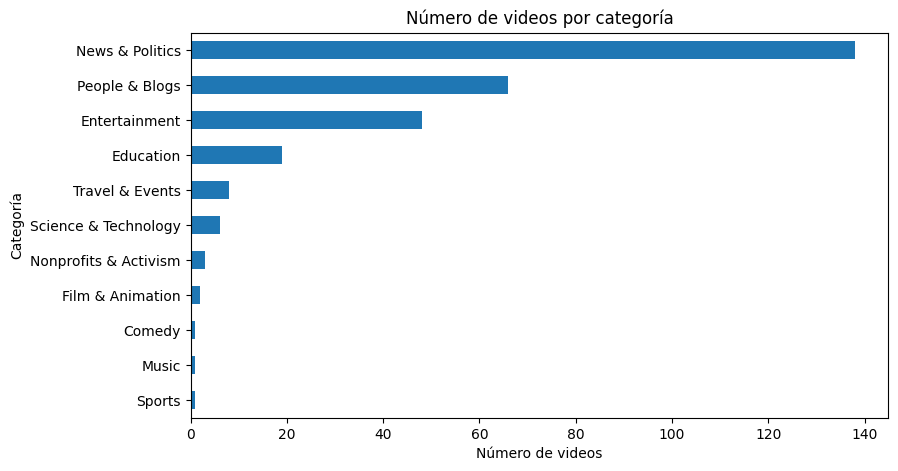

In [49]:
# categorias 
categorias = (
    videos["category"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 5))

categorias.plot(kind="barh")

plt.title("Número de videos por categoría")
plt.xlabel("Número de videos")
plt.ylabel("Categoría")

plt.show()

La categoría predominante es `News & Politics`, con 138 de los 293 videos
del conjunto, seguida por `People & Blogs` y `Entertainment`.

Esto indica que la muestra presenta una fuerte presencia de contenido
político, informativo y de actualidad. Sin embargo, esta distribución
también está influenciada por las consultas utilizadas durante el proceso
de recolección.

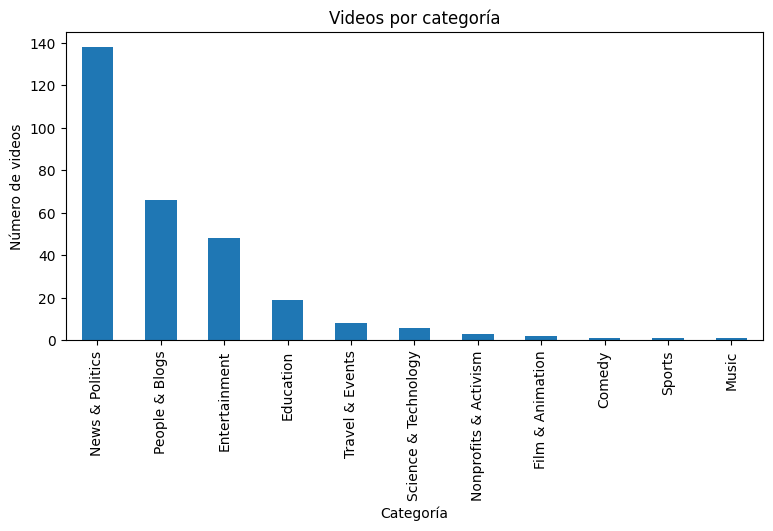

In [50]:
videos["category"].value_counts().plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("Videos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de videos")

plt.show()

In [51]:
videos["source_query"].value_counts().head(15)

source_query
Municipalidad de Guatemala                20
Gobierno de Guatemala                     18
@GobiernodelaRepublicadeGuatema           18
@GobiernodeGuatemala                      17
guatemala noticias                        16
Ministerio de Comunicaciones Guatemala    16
@MunicipalidaddeGuatemala-1551            16
Gobierno de la República de Guatemala     15
PMT Guatemala                             15
Conred Guatemala                          15
Provial Guatemala                         13
guatemala trafico                         13
guatemala transporte                      13
Policia Nacional Civil Guatemala          13
guatemala lluvias                         12
Name: count, dtype: int64

In [52]:
# hashtags
hashtags = (
    comments["texto_original"]
    .fillna("")
    .str.findall(r"#\w+")
    .explode()
    .dropna()
    .str.lower()
)

hashtags.value_counts().head(15)


texto_original
#ineptobran    1
Name: count, dtype: int64

In [53]:
palabras = []

for texto in comments["texto_limpio"]:

    for palabra in texto.split():

        if (
            palabra not in stopwords_es
            and len(palabra) > 2
        ):
            palabras.append(palabra)

frecuencias = Counter(palabras)

frecuencias.most_common(20)

[('pueblo', 56),
 ('guatemala', 52),
 ('pero', 44),
 ('este', 42),
 ('les', 39),
 ('porque', 38),
 ('eso', 36),
 ('ese', 35),
 ('hay', 35),
 ('son', 35),
 ('más', 35),
 ('dinero', 34),
 ('solo', 33),
 ('todos', 33),
 ('presidente', 32),
 ('país', 31),
 ('todo', 31),
 ('trabajo', 30),
 ('estos', 30),
 ('diputados', 28)]

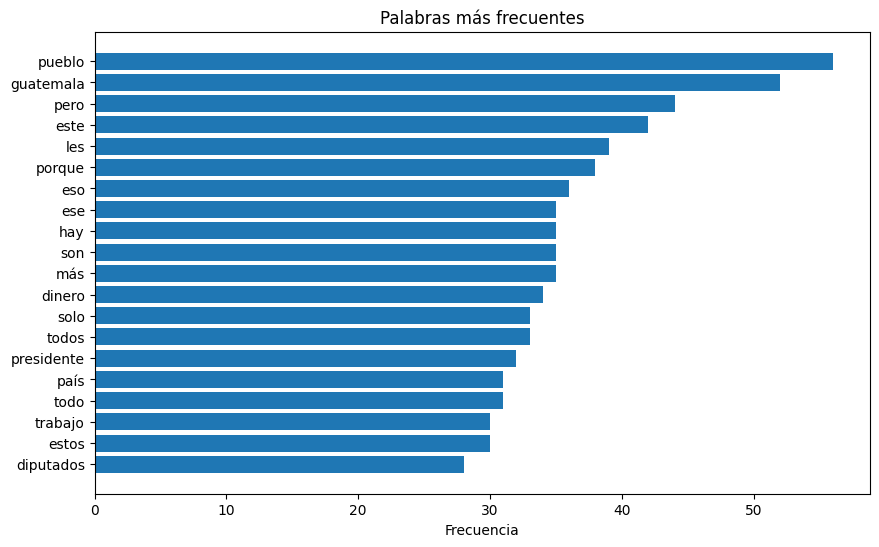

In [54]:
palabras_frecuentes = pd.DataFrame(
    frecuencias.most_common(20),
    columns=["palabra", "frecuencia"]
)

palabras_frecuentes
plt.figure(figsize=(10, 6))

plt.barh(
    palabras_frecuentes["palabra"],
    palabras_frecuentes["frecuencia"]
)

plt.gca().invert_yaxis()

plt.title("Palabras más frecuentes")
plt.xlabel("Frecuencia")

plt.show()

Notamos que la mayoría de los comentarios no tienen respuestas, pero hay algunos comentarios con muchas respuestas. Esto puede indicar que ciertos comentarios generan más discusión o interacción que otros. Además que la frecuencia de ciertas palabras en los comentarios puede indicar temas recurrentes o tendencias en la conversación como por ejemplo guatemala, pueblo y dinero. Las demás solamente aparecen porque son muy usadas para unir palabras como "para", "con" y "que".

In [55]:
palabras = []

for texto in comments["texto_limpio"]:

    for palabra in texto.split():

        if (
            palabra not in stopwords_es
            and len(palabra) > 2
        ):
            palabras.append(palabra)

frecuencias = Counter(palabras)
frecuencias.most_common(20)

[('pueblo', 56),
 ('guatemala', 52),
 ('pero', 44),
 ('este', 42),
 ('les', 39),
 ('porque', 38),
 ('eso', 36),
 ('ese', 35),
 ('hay', 35),
 ('son', 35),
 ('más', 35),
 ('dinero', 34),
 ('solo', 33),
 ('todos', 33),
 ('presidente', 32),
 ('país', 31),
 ('todo', 31),
 ('trabajo', 30),
 ('estos', 30),
 ('diputados', 28)]

In [56]:
# Bigramas 
bigramas = []

for texto in comments["texto_limpio"]:

    tokens = [
        palabra
        for palabra in texto.split()
        if palabra not in stopwords_es
        and len(palabra) > 2
    ]

    for i in range(len(tokens) - 1):

        bigrama = (
            tokens[i],
            tokens[i + 1]
        )

        bigramas.append(bigrama)

In [57]:
Counter(bigramas).most_common(20)

[(('presidente', 'bernardo'), 9),
 (('bernardo', 'arevalo'), 8),
 (('saludos', 'desde'), 8),
 (('ese', 'dinero'), 6),
 (('ciudad', 'guatemala'), 6),
 (('nery', 'rodas'), 5),
 (('bla', 'bla'), 5),
 (('estos', 'diputados'), 5),
 (('pacto', 'corruptos'), 5),
 (('busquen', 'otro'), 4),
 (('otro', 'trabajo'), 4),
 (('hacer', 'algo'), 4),
 (('este', 'diputado'), 4),
 (('ese', 'diputado'), 4),
 (('nada', 'bueno'), 4),
 (('ser', 'diputados'), 4),
 (('lleva', 'años'), 4),
 (('dinero', 'pueblo'), 4),
 (('comida', 'nadie'), 4),
 (('guatemala', 'saludos'), 4)]

In [58]:
# ¿pocos videos concentran gran parte de los comentarios?
comentarios_video = (
    comments
    .groupby("video_id")
    .size()
    .sort_values(ascending=False)
)

In [59]:
participacion_acumulada = (
    comentarios_video.cumsum()
    / comentarios_video.sum()
)

participacion_acumulada.head(10)

video_id
n8iP75gIpmw    0.396552
j43HgwYFKfk    0.519704
6W4u8sGEnGM    0.630542
lj983NWyAQY    0.692118
PjmxCj-a9Hg    0.753695
OkXlHx0hx-8    0.815271
yLZS3JiEBg8    0.854680
06mFNPU0aB8    0.889163
ndAZjHqzzT8    0.918719
is3Mk5oC19g    0.935961
dtype: float64

In [60]:
# top10 
top10_prop = (
    comentarios_video.head(10).sum()
    / comentarios_video.sum()
)

print(
    f"Los 10 videos con más comentarios concentran "
    f"{top10_prop:.2%} de los comentarios."
)

Los 10 videos con más comentarios concentran 93.60% de los comentarios.


In [61]:
# por canal 
comentarios_canal = (
    comments
    .groupby("channel_id")
    .size()
    .sort_values(ascending=False)
)

top5_canales = (
    comentarios_canal.head(5).sum()
    / comentarios_canal.sum()
)

print(
    f"Los 5 canales con más participación concentran "
    f"{top5_canales:.2%} de los comentarios."
)

Los 5 canales con más participación concentran 96.06% de los comentarios.


In [62]:
# visualizacion vs comentarios 
comentarios_por_video = (
    comments
    .groupby("video_id")
    .size()
    .reset_index(name="comentarios")
)

In [63]:
popularidad = videos.merge(
    comentarios_por_video,
    on="video_id",
    how="left"
)

In [64]:
popularidad["comentarios"] = (
    popularidad["comentarios"]
    .fillna(0)
)

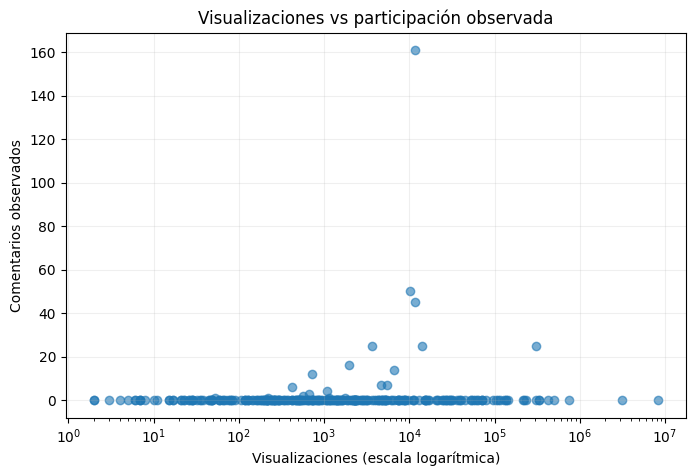

In [65]:
plt.figure(figsize=(8, 5))

plt.scatter(
    popularidad["view_count"],
    popularidad["comentarios"],
    alpha=0.6
)

plt.xscale("log")

plt.xlabel("Visualizaciones (escala logarítmica)")
plt.ylabel("Comentarios observados")
plt.title("Visualizaciones vs participación observada")

plt.grid(alpha=0.2)

plt.show()

parece ser que pocos videos concentran gran parte de los comentarios, lo que puede indicar que ciertos videos son más populares o generan más interacción que otros.  
Además, las visualizaciones corresponden al conteo observado al momento de la
recolección, mientras que el conjunto de comentarios no necesariamente contiene
todos los comentarios existentes en cada video. Por ello, ambos valores deben
compararse con precaución.

In [66]:
pearson = popularidad[
    ["view_count", "comentarios"]
].corr(method="pearson").iloc[0, 1]

spearman = popularidad[
    ["view_count", "comentarios"]
].corr(method="spearman").iloc[0, 1]

print(f"Correlación de Pearson: {pearson:.3f}")
print(f"Correlación de Spearman: {spearman:.3f}")

Correlación de Pearson: -0.008
Correlación de Spearman: 0.080


Pearson puede verse muy afectada por los videos con millones de views.

Spearman analiza principalmente el orden/rango y será útil en una distribución tan desigual.

Después de correrlo, esos dos números te permiten responder con mucha más seguridad.

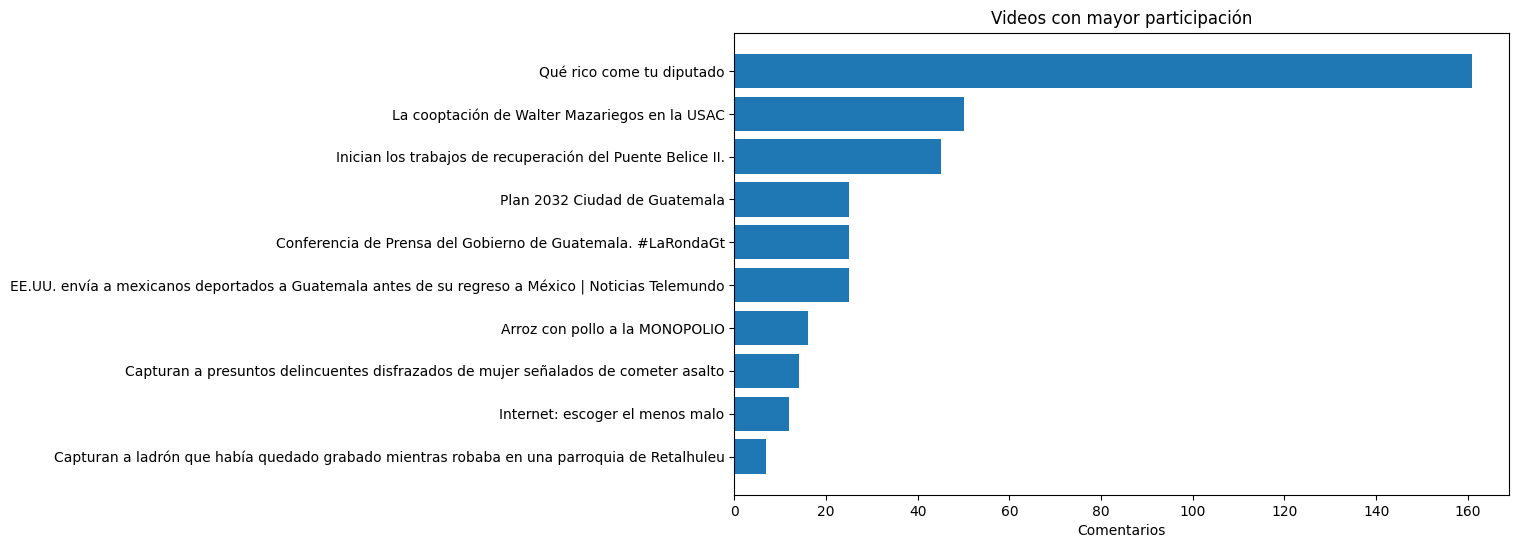

In [67]:
top_videos = participacion_video.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_videos["video_title"],
    top_videos["comentarios"]
)

plt.gca().invert_yaxis()

plt.xlabel("Comentarios")
plt.title("Videos con mayor participación")

plt.show()

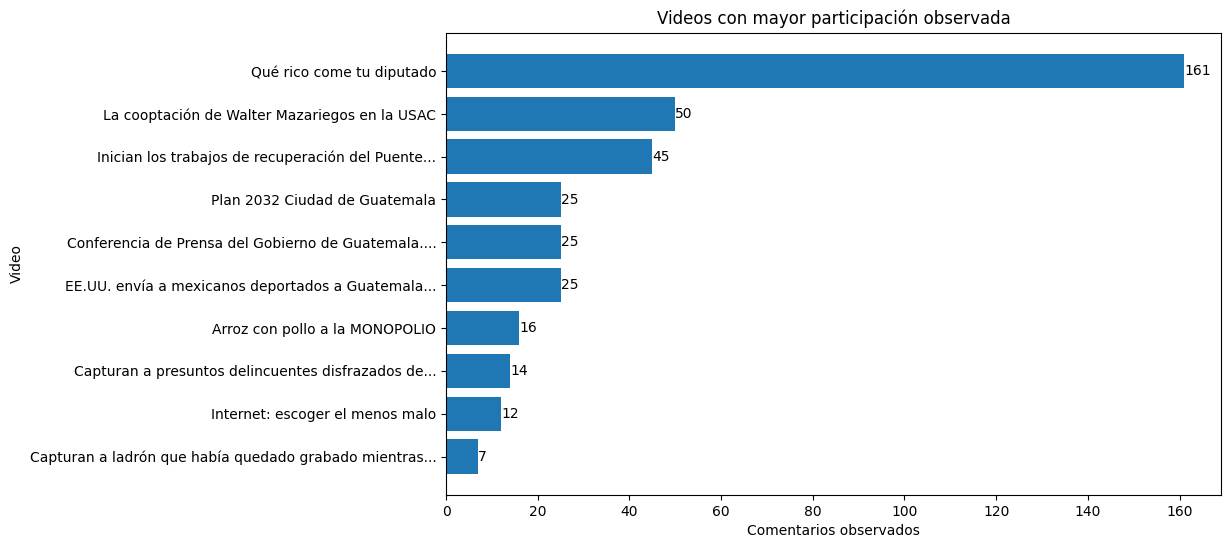

In [68]:
top_videos = participacion_video.head(10).copy()

top_videos["titulo_corto"] = (
    top_videos["video_title"]
    .apply(
        lambda x: textwrap.shorten(
            x,
            width=55,
            placeholder="..."
        )
    )
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_videos["titulo_corto"],
    top_videos["comentarios"]
)

plt.gca().invert_yaxis()

plt.xlabel("Comentarios observados")
plt.ylabel("Video")
plt.title("Videos con mayor participación observada")

plt.bar_label(bars)

plt.show()

In [69]:
participacion_canal = (
    comments
    .groupby(["channel_id", "channel_name"])
    .agg(
        comentarios=("comment_id", "count"),
        autores_unicos=("author_channel_id", "nunique"),
        videos_comentados=("video_id", "nunique")
    )
    .reset_index()
    .sort_values("comentarios", ascending=False)
)

participacion_canal.head(10)

,channel_id,channel_name,comentarios,autores_unicos,videos_comentados
1,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,256,214,11
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,70,50,2
3,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,25,18,1
5,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,25,25,1
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,14,13,1
2,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,7,7,1
7,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,7,1
6,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,2,1


In [70]:
#Audienciad compartidas? 
participacion_autor = (
    comments
    .groupby(["author_channel_id", "author_name"])
    .agg(
        comentarios=("comment_id", "count"),
        videos_distintos=("video_id", "nunique"),
        canales_distintos=("channel_id", "nunique")
    )
    .reset_index()
)

autores_multivideo = (
    participacion_autor["videos_distintos"] > 1
).sum()

autores_multicanal = (
    participacion_autor["canales_distintos"] > 1
).sum()

print("Autores que participaron en más de un video:",
      autores_multivideo)

print("Autores que participaron en más de un canal:",
      autores_multicanal)

Autores que participaron en más de un video: 9
Autores que participaron en más de un canal: 4


In [71]:
participacion_autor.sort_values(
    ["videos_distintos", "canales_distintos", "comentarios"],
    ascending=False
).head(10)

,author_channel_id,author_name,comentarios,videos_distintos,canales_distintos
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,4,3,1
276,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,3,1
98,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,3,2,2
211,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,2,2,2
250,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2,2
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2,2
325,UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,3,2,1
207,UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,2,2,1
330,UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,2,1
241,UCi2KiZq63sRq8Mfbcp-MelQ,@eugeneramirez4405,6,1,1


In [72]:
# Candidatos a autores puente entre contenidos
autores_puente_exploratorio = (
    comments
    .groupby(
        ["author_channel_id", "author_name", "author_handle"],
        dropna=False
    )
    .agg(
        comentarios=("comment_id", "count"),
        videos_distintos=("video_id", "nunique"),
        canales_distintos=("channel_id", "nunique")
    )
    .reset_index()
)

autores_puente_exploratorio = (
    autores_puente_exploratorio[
        autores_puente_exploratorio["canales_distintos"] > 1
    ]
    .sort_values(
        ["canales_distintos", "videos_distintos", "comentarios"],
        ascending=False
    )
)

autores_puente_exploratorio[
    [
        "author_handle",
        "author_name",
        "videos_distintos",
        "canales_distintos",
        "comentarios"
    ]
].head(10)


,author_handle,author_name,videos_distintos,canales_distintos,comentarios
98,/@virgiliogarcia3039,@virgiliogarcia3039,2,2,3
211,/@MarcosCarillo-b1r,@MarcosCarillo-b1r,2,2,2
250,/@franciscoflores3120,@franciscoflores3120,2,2,2
287,/@moisesvaldez4043,@moisesvaldez4043,2,2,2


### 3.5 Preguntas de investigación

#### ¿Qué videos y canales concentran la mayor participación observada?

Podemos ver que la articipacion presenta una concentración en unos pocos videos y canales, el video de "Que rico como tu diputado" contiene 161 comentarios provenientes de 128 autores únicos y, por sí solo también concentra el 39.66% de todos los comentarios de la muestra.

LUego le sigue el "La cooptacion de Walter Mazariegos en la USAC" con 50 comentarios y "Inician los trabajos de recuperación del Puente Belice II" con 45. En total los 10 videos con mayor participación concentran el **93.60%** de todos los comentarios observados.

Con respecto al canal, los cinco canales con mayor participación concentran el **96.06%** de todos los comentarios observados como lo son Quorum y Gobierno de la Reública de Guatemala que contienen la gran parte de los comentarios. 

#### ¿Existen audiencias compartidas entre videos, canales o temas?

Existen audiencias compartidas entre videos, canales y temas, lo que indica que ciertos usuarios participan en múltiples videos o canales relacionados. Esto puede reflejar intereses comunes o la influencia de ciertos temas en la comunidad.
Se identificaron a **9 autores** que actúan como puentes entre diferentes contenidos. y dentro de ellos, **4 autores** que participaron en videos pertenecientes a más de un canal. 

Esto nos puede decir que hay algunos usuarios cuya participación no de limita a un solo contenido, sino que abarcan más espacio en diferentes videos e incluso en otros canales. Sin embargo, este tipo de co-participación únicamente indica que un mismo autor comentó en distintos contenidos. No significa de que exista algún tipo de amistas, comunicación directa o afinidad entre los dos. 

#### ¿Qué autores funcionan como puentes entre contenidos?

Como aproximación exploratoria, pueden considerarse candidatos a autores
puente aquellos que participan en videos pertenecientes a más de un canal.

En la muestra se identificaron cuatro autores con este comportamiento:

- `@virgiliogarcia3039`
- `@MarcosCarillo-b1r`
- `@franciscoflores3120`
- `@moisesvaldez4043`

Cada uno participó en dos videos pertenecientes a dos canales diferentes,
por lo que contribuye a conectar contenidos que pertenecen a espacios
distintos dentro de la muestra. Sin embargo, no se puede inferir que exista comunicación directa entre los autores ni que compartan afinidad o intereses, ya que la co-participación únicamente indica que un mismo autor comentó en distintos contenidos.

#### ¿Qué temas y sentimientos caracterizan las principales comunidades?
el análisis de palabras y bigramas permite observar que una parte
importante de la conversación está relacionada con temas políticos, gobierno,
diputados, autoridades y asuntos públicos de Guatemala.

Entre los bigramas frecuentes aparecen expresiones como
`presidente bernardo`, `bernardo arevalo`, `ciudad guatemala`,
`estos diputados`, `pacto corruptos` y `dinero pueblo`.

Estos resultados sugieren una presencia importante de conversación política
y de discusión sobre autoridades públicas. La identificación formal de
comunidades y su sentimiento deberá realizarse posteriormente utilizando
la estructura de la red y un método específico de análisis de sentimiento.


#### ¿La visibilidad medida mediante visualizaciones coincide con la participación observada?
No se observa una correspondencia clara entre el número de visualizaciones
y la participación representada por los comentarios disponibles en la muestra.

Algunos videos presentan millones de visualizaciones pero poca o ninguna
participación dentro del conjunto de comentarios recolectado, mientras que
otros videos con menor número de visualizaciones concentran una cantidad
considerablemente mayor de comentarios.

Por ejemplo, el video con mayor cantidad de visualizaciones supera los
8 millones de vistas, pero no aparece entre los contenidos con mayor número
de comentarios observados. En cambio, “Qué rico come tu diputado” concentra
161 comentarios.

Por lo tanto, las visualizaciones y los comentarios representan dimensiones
diferentes de popularidad y participación y no deben utilizarse como medidas
equivalentes.


#### ¿Qué conclusiones están limitadas por el procedimiento de recolección?
Tenemos algunas limitaciones con respecto al procedimiento de recolección ya por ejemplo: 

- `youtube_comments.csv` contiene comentarios de una selección de videos y no necesariamente todos los comentarios existentes en YouTube.

- todos los videos fueron obtenidos mediante consultas específicas de búsqueda, por lo que la selección de términos utilizada durante la recolección influye directamente sobre el contenido presente en el dataset.

- algunas variables temporales se encuentran expresadas de manera relativa y los conteos de visualizaciones, respuestas y "me gusta" corresponden al momento en que fueron recolectados.

- Adicionalmente, el dataset no identifica quién respondió a quién. `reply_count` indica únicamente la cantidad de respuestas recibidas, por lo que no puede utilizarse para crear relaciones directas entre autores.

- los comentarios se encuentran fuertemente concentrados en unos pocos videos. Por estas razones los resultados describen únicamente la muestra observada y no pueden generalizarse a todos los usuarios de YouTube ni a toda la población de Guatemala.

### 3.6 Preguntas adicionales

#### **1. ¿Los videos con más comentarios también presentan mayor diversidad de autores?**

Sí se observa una relación positiva entre la cantidad de comentarios y la
cantidad de autores únicos.

Por ejemplo, el video con mayor participación registra 161 comentarios
producidos por 128 autores únicos; el segundo presenta 50 comentarios de
49 autores y el tercero 45 comentarios de 32 autores.

Esto indica que la alta participación no proviene únicamente de un pequeño
número de usuarios comentando repetidamente, sino también de una mayor
cantidad de participantes diferentes. Sin embargo, algunos autores pueden
publicar más de un comentario, por lo que ambas medidas no son equivalentes.

#### **2. ¿Qué canales tienen el mayor promedio de comentarios por video?**

Podemos notar que el canal con mayor promedio de comentarios por video dentro de la muestra es **Quorum** que son aprox **14.22 comentarios por video** . Luego le sigue **Noticias Telemundo** con **12.50 comentarios por video**. y **Noti7** con **4.67 comentarios por video**. 
Podemos notar que no necesariamente tener una mayor cantidad de videos como lo puede ser por ejemplo **Gobierno de la República de Guatemala** el cual representa aproximadamente **2.19 comentarios por video** represente un mayor nivel promedio de participación.  Ya que el Gobierno tiene casi el sobre de videos que Quorum, este tiene muchísimo más promedio de participación en sus videos. 

#### **3. ¿Los comentarios que reciben más respuestas también reciben más "me gusta"?**
Usualmente tomamos en cuenta de que entre más respuestas hay, tiene que tener más likes. Con eso implementamos una correlación de Spearman que entre el número de respuestas y número de "likes" fue aproximadamente de **0.218** Esto es un valor positivo pero muy bajo, lo que nos indica una asociación positiv débil entre ambas variables. 

Esto nos puede decir que los comentarios que se reciben más respuestas pueden tender ligeramente a recibir más "likes" pero no lo necesariamente fuerte para indicar de que ambas formas de interacción están correlacionadas. Además podemos notar que la cuenta de likes presenta valores disponibles para 217 de los 406 comentarios, lo que esta comparación también indica una limitación en la muestra y que no necesariamente todos los comentarios tienen información completa sobre "likes".

Evidencias de preguntas extras:

In [73]:
participacion_video[
    ["comentarios", "autores_unicos"]
].corr()


,comentarios,autores_unicos
comentarios,1.000000,0.995822
autores_unicos,0.995822,1.000000


In [74]:
comentarios_canal_df = (
    comments
    .groupby(["channel_id", "channel_name"])
    .size()
    .reset_index(name="comentarios")
)

videos_canal_df = (
    videos
    .groupby(["channel_id", "channel_name"])
    .size()
    .reset_index(name="videos")
)
metricas_canal = comentarios_canal_df.merge(
    videos_canal_df,
    on="channel_id",
    suffixes=("_comments", "_videos")
)
metricas_canal["comentarios_por_video"] = (
    metricas_canal["comentarios"]
    / metricas_canal["videos"]
)

metricas_canal.sort_values(
    "comentarios_por_video",
    ascending=False
).head(10)

,channel_id,channel_name_comments,comentarios,channel_name_videos,videos,comentarios_por_video
1,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,256,Quorum,18,14.222222
3,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,25,Noticias Telemundo,2,12.500000
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,14,Noti7,3,4.666667
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,70,Gobierno de la República de Guatemala,32,2.187500
7,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,TN23 Guatemala,7,1.000000
6,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,Noticiero Guatevisión 13 Hrs.,2,1.000000
5,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,25,Municipalidad de Guatemala,27,0.925926
2,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,7,PrensaLibreOficial,17,0.411765


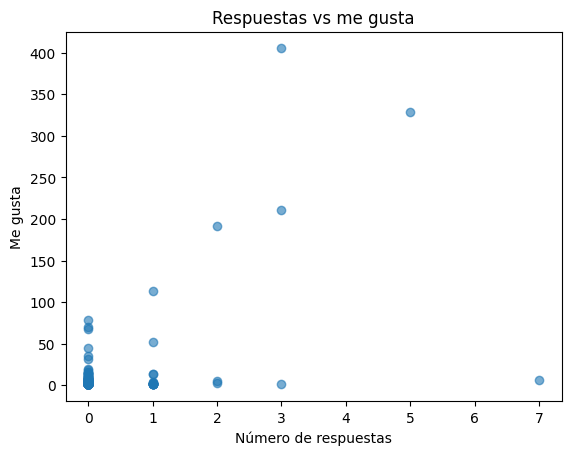

In [75]:
comments[
    ["reply_count", "like_count"]
].corr()
plt.scatter(
    comments["reply_count"],
    comments["like_count"],
    alpha=0.6
)

plt.xlabel("Número de respuestas")
plt.ylabel("Me gusta")
plt.title("Respuestas vs me gusta")

plt.show()

In [76]:
videos_por_canal_total = (
    videos
    .groupby(["channel_id", "channel_name"])
    .size()
    .reset_index(name="videos")
)

comentarios_por_canal_total = (
    comments
    .groupby("channel_id")
    .size()
    .reset_index(name="comentarios")
)

promedio_canal = videos_por_canal_total.merge(
    comentarios_por_canal_total,
    on="channel_id",
    how="left"
)

promedio_canal["comentarios"] = (
    promedio_canal["comentarios"]
    .fillna(0)
)

promedio_canal["comentarios_por_video"] = (
    promedio_canal["comentarios"]
    / promedio_canal["videos"]
)

promedio_canal.sort_values(
    "comentarios_por_video",
    ascending=False
).head(10)

,channel_id,channel_name,videos,comentarios,comentarios_por_video
26,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,18,256.0,14.222222
44,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,2,25.0,12.500000
50,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,3,14.0,4.666667
3,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,32,70.0,2.187500
87,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,7.0,1.000000
66,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,2.0,1.000000
54,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,27,25.0,0.925926
28,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,17,7.0,0.411765
0,UC-DpoeBbCMOMOH1-j71KPqA,México Poder,1,0.0,0.000000
9,UC6Y7Hk0Otm2xeX1WoHOQp6Q,Nostalgia Latina,1,0.0,0.000000


In [77]:
# respuestas vs likes 
respuestas_likes = (
    comments[
        ["reply_count", "like_count"]
    ]
    .dropna()
)

corr_respuestas_likes = (
    respuestas_likes
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    f"Correlación de Spearman: "
    f"{corr_respuestas_likes:.3f}"
)

Correlación de Spearman: 0.218


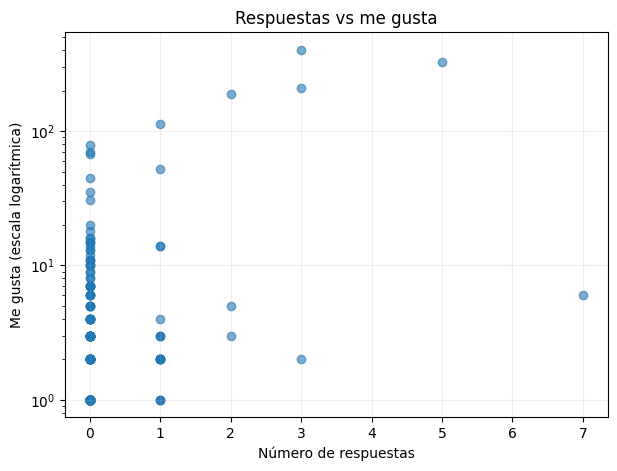

In [78]:
plt.figure(figsize=(7, 5))

plt.scatter(
    respuestas_likes["reply_count"],
    respuestas_likes["like_count"],
    alpha=0.6
)

plt.yscale("log")

plt.xlabel("Número de respuestas")
plt.ylabel("Me gusta (escala logarítmica)")
plt.title("Respuestas vs me gusta")

plt.grid(alpha=0.2)

plt.show()

## 4. Construcción de la red bipartita autor-video

Se construirá una red bipartita no dirigida.

Los nodos pertenecen a dos grupos:

- autores;
- videos.

Existe una arista entre un autor y un video cuando ese autor publicó al menos
un comentario en ese video.

El peso representa la cantidad de comentarios publicados por ese autor
en ese video.

Cada combinación única autor-video representa una arista.

Si un mismo autor publicó varios comentarios en el mismo video, no se crean
varias aristas independientes. En su lugar, la cantidad de comentarios se
almacena como el peso de la arista.

In [79]:
aristas = (
    comments
    .groupby(
        ["author_channel_id", "video_id"]
    )
    .size()
    .reset_index(name="peso")
)

aristas.head(10)

,author_channel_id,video_id,peso
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1
5,UC-jS_kA9w-OmpupXDx156Rg,n8iP75gIpmw,1
6,UC-pNP6RMFuLg_-x7Ah_0kEA,n8iP75gIpmw,1
7,UC094EFEmMSdwVa8NQjjYBXg,b_Hkrkl3adA,1
8,UC0HvfEWozTHbwl_iEmJNvVA,6W4u8sGEnGM,1
9,UC0RpuMwkDKJYqgKHtsJRuWQ,lj983NWyAQY,1


In [80]:
print("Número de aristas:", len(aristas))

print(
    "Suma de los pesos:",
    aristas["peso"].sum()
)

print(
    "Número total de comentarios:",
    len(comments)
)

Número de aristas: 343
Suma de los pesos: 406
Número total de comentarios: 406


### 4.3 Construcción de la tabla de nodos

La red contiene dos tipos de nodos: autores y videos.

Para identificar de forma estable a los autores se utiliza `author_channel_id`,
mientras que para los videos se utiliza `video_id`.

Los nombres, handles y títulos se conservan como atributos descriptivos,
pero no sustituyen los identificadores originales.

In [ ]:
# nodos correspondientes a autores

nodos_autores = (
    comments[
        [
            "author_channel_id",
            "author_name",
            "author_handle"
        ]
    ]
    .drop_duplicates(
        subset="author_channel_id"
    )
    .copy()
)

# partimos de comentarios, pero un mismo autor puede aparecer muchas veces 
# Esto nos ayuda a que cada autor aparezca una sola vez
nodos_autores.head()

,author_channel_id,author_name,author_handle
0,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,/@MarcosCarillo-b1r
1,UCvl1tzQeBeGy6efPTRJXSCw,@RaulPerez-cw2vi,/@RaulPerez-cw2vi
2,UCRAquv8el-tQ30bN7MlmySQ,@iamjimalesssa,/@iamjimalesssa
3,UCkbsS_3D-pvg1iHOld9uvIg,@gonzalo6075,/@gonzalo6075
4,UCOLHH4ZpMxPYF-Q6e6wvn5A,@luisroldan7374,/@luisroldan7374


In [144]:
# Tipo de nodo y un identificador para NetworkX
nodos_autores["tipo"] = "autor"

nodos_autores["node_id"] = (
    "autor::"
    + nodos_autores["author_channel_id"].astype(str)
)

nodos_autores.head()

,author_channel_id,author_name,author_handle,tipo,node_id
0,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,/@MarcosCarillo-b1r,autor,autor::UCdFlugHJJa4l3YqWuNRmvXw
1,UCvl1tzQeBeGy6efPTRJXSCw,@RaulPerez-cw2vi,/@RaulPerez-cw2vi,autor,autor::UCvl1tzQeBeGy6efPTRJXSCw
2,UCRAquv8el-tQ30bN7MlmySQ,@iamjimalesssa,/@iamjimalesssa,autor,autor::UCRAquv8el-tQ30bN7MlmySQ
3,UCkbsS_3D-pvg1iHOld9uvIg,@gonzalo6075,/@gonzalo6075,autor,autor::UCkbsS_3D-pvg1iHOld9uvIg
4,UCOLHH4ZpMxPYF-Q6e6wvn5A,@luisroldan7374,/@luisroldan7374,autor,autor::UCOLHH4ZpMxPYF-Q6e6wvn5A


utilizamos una red con un nuevo nodo de autor:: esto evita que cualquier posibilidad de que un autor_channel_id coincida accidentalmente con algun video_id. 

#### videos
para el caso de videos no vamos a colocar todos los 293 videos como nodos ya que algunos no aportan información de participación por medio de comentarios. Si agremaos videos que nunca estuvieron cubiertos por el dataset de comentarios, podríamos aparentar de que tiene "cero participación" , cuando en realidad puede ser que simplemente no tenga comentarios. 

In [146]:
# identificadores de videos que aparecen en los comentarios

videos_con_comentarios = (
    comments["video_id"]
    .dropna()
    .unique()
)

len(videos_con_comentarios)

19

In [147]:
# nodos correspondientes a videos

nodos_videos = (
    videos[
        videos["video_id"].isin(videos_con_comentarios)
    ][
        [
            "video_id",
            "title",
            "channel_id",
            "channel_name",
            "category",
            "view_count"
        ]
    ]
    .drop_duplicates(
        subset="video_id"
    )
    .copy()
)

nodos_videos.head()

,video_id,title,channel_id,channel_name,category,view_count
4,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,News & Politics,6692
21,3Nfp9h5avBI,"Noticiero en Directo 1 pm, 28 de Agosto de 2026",UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,News & Politics,573
38,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,Entertainment,11670
106,JkpVO1hx2f8,10 Preguntas a un año del Paro Nacional,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,673
130,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,News & Politics,14200


In [148]:
nodos_videos["tipo"] = "video"

nodos_videos["node_id"] = (
    "video::"
    + nodos_videos["video_id"].astype(str)
)

nodos_videos.head()

,video_id,title,channel_id,channel_name,category,view_count,tipo,node_id
4,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,News & Politics,6692,video,video::06mFNPU0aB8
21,3Nfp9h5avBI,"Noticiero en Directo 1 pm, 28 de Agosto de 2026",UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,News & Politics,573,video,video::3Nfp9h5avBI
38,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,Entertainment,11670,video,video::6W4u8sGEnGM
106,JkpVO1hx2f8,10 Preguntas a un año del Paro Nacional,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,673,video,video::JkpVO1hx2f8
130,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,News & Politics,14200,video,video::OkXlHx0hx-8


In [149]:
print(
    "numero de autores:", len(nodos_autores)
)

print(
    "numero de videos con participacion: ", len(nodos_videos)
)

numero de autores: 332
numero de videos con participacion:  19


In [150]:
#tablas 
# necesitamos que autores y videos formen una sola tabla
tabla_autores = pd.DataFrame({
    "node_id": nodos_autores["node_id"],
    "id_original": nodos_autores["author_channel_id"],
    "tipo": "autor",
    "nombre": nodos_autores["author_name"],
    "handle": nodos_autores["author_handle"]
})

tabla_videos = pd.DataFrame({
    "node_id": nodos_videos["node_id"],
    "id_original": nodos_videos["video_id"],
    "tipo": "video",
    "nombre": nodos_videos["title"],
    "canal": nodos_videos["channel_name"],
    "categoria": nodos_videos["category"],
    "visualizaciones": nodos_videos["view_count"]
})

In [151]:
tabla_nodos = pd.concat(
    [
        tabla_autores,
        tabla_videos
    ],
    ignore_index=True
)

tabla_nodos.head(10)

,node_id,id_original,tipo,nombre,handle,canal,categoria,visualizaciones
0,autor::UCdFlugHJJa4l3YqWuNRmvXw,UCdFlugHJJa4l3YqWuNRmvXw,autor,@MarcosCarillo-b1r,/@MarcosCarillo-b1r,<NA>,NaN,NaN
1,autor::UCvl1tzQeBeGy6efPTRJXSCw,UCvl1tzQeBeGy6efPTRJXSCw,autor,@RaulPerez-cw2vi,/@RaulPerez-cw2vi,<NA>,NaN,NaN
2,autor::UCRAquv8el-tQ30bN7MlmySQ,UCRAquv8el-tQ30bN7MlmySQ,autor,@iamjimalesssa,/@iamjimalesssa,<NA>,NaN,NaN
3,autor::UCkbsS_3D-pvg1iHOld9uvIg,UCkbsS_3D-pvg1iHOld9uvIg,autor,@gonzalo6075,/@gonzalo6075,<NA>,NaN,NaN
4,autor::UCOLHH4ZpMxPYF-Q6e6wvn5A,UCOLHH4ZpMxPYF-Q6e6wvn5A,autor,@luisroldan7374,/@luisroldan7374,<NA>,NaN,NaN
5,autor::UCi2KiZq63sRq8Mfbcp-MelQ,UCi2KiZq63sRq8Mfbcp-MelQ,autor,@eugeneramirez4405,/@eugeneramirez4405,<NA>,NaN,NaN
6,autor::UCXl30Y_upRqbti52fmjK4YA,UCXl30Y_upRqbti52fmjK4YA,autor,@capitanfrans,/@capitanfrans,<NA>,NaN,NaN
7,autor::UCRelkU8JiZBytTzebJxaa-w,UCRelkU8JiZBytTzebJxaa-w,autor,@danyraymundo2942,/@danyraymundo2942,<NA>,NaN,NaN
8,autor::UCgLurCo-e019HGODcjXHWCw,UCgLurCo-e019HGODcjXHWCw,autor,@perritojuega1,/@perritojuega1,<NA>,NaN,NaN
9,autor::UCDIMztpVm7G27qBuiWuT6oQ,UCDIMztpVm7G27qBuiWuT6oQ,autor,@lizardomorataya8274,/@lizardomorataya8274,<NA>,NaN,NaN


In [152]:
tabla_nodos.tail(10)

,node_id,id_original,tipo,nombre,handle,canal,categoria,visualizaciones
341,video::X_FAIef8qlE,X_FAIef8qlE,video,Cruzando la ciudad a puro Transmetro,<NA>,Quorum,News & Politics,1140.0
342,video::b_Hkrkl3adA,b_Hkrkl3adA,video,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales,<NA>,PrensaLibreOficial,News & Politics,5469.0
343,video::is3Mk5oC19g,is3Mk5oC19g,video,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalhuleu,<NA>,TN23 Guatemala,News & Politics,4616.0
344,video::j43HgwYFKfk,j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,<NA>,Quorum,News & Politics,10156.0
345,video::lj983NWyAQY,lj983NWyAQY,video,Plan 2032 Ciudad de Guatemala,<NA>,Municipalidad de Guatemala,News & Politics,304089.0
346,video::n8iP75gIpmw,n8iP75gIpmw,video,Qué rico come tu diputado,<NA>,Quorum,News & Politics,11775.0
347,video::ndAZjHqzzT8,ndAZjHqzzT8,video,Internet: escoger el menos malo,<NA>,Quorum,News & Politics,717.0
348,video::s0eco-BofOs,s0eco-BofOs,video,¿Quiénes pagan más en Centroamérica?,<NA>,Quorum,News & Politics,220.0
349,video::yLZS3JiEBg8,yLZS3JiEBg8,video,Arroz con pollo a la MONOPOLIO,<NA>,Quorum,News & Politics,1954.0
350,video::zweosulrwA8,zweosulrwA8,video,Edén por Salud: empleo inclusivo para personas con discapacidad en Antigua | Super - Episodio 2,<NA>,Quorum,Nonprofits & Activism,52.0


In [153]:
tabla_nodos["tipo"].value_counts()

tipo
autor    332
video     19
Name: count, dtype: int64

In [154]:
print("Número total de nodos:", len(tabla_nodos))

Número total de nodos: 351


In [155]:
aristas["source"] = (
    "autor::"
    + aristas["author_channel_id"].astype(str)
)

aristas["target"] = (
    "video::"
    + aristas["video_id"].astype(str)
)

In [156]:
aristas[
    [
        "source",
        "target",
        "author_channel_id",
        "video_id",
        "peso"
    ]
].head(10)

,source,target,author_channel_id,video_id,peso
0,autor::UC-HeUTT6_g-VoiWds2a4H-w,video::6W4u8sGEnGM,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,autor::UC-Iul5tDYH_oiAMXQH-KaaQ,video::6W4u8sGEnGM,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,autor::UC-QOpE7GOxlXcHZ8b7HbQKA,video::OkXlHx0hx-8,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,autor::UC-fiZBS5Gp1eCJd9ucgWnCg,video::j43HgwYFKfk,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,autor::UC-hfX8J5JPJ-dfuakzegMLA,video::n8iP75gIpmw,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1
5,autor::UC-jS_kA9w-OmpupXDx156Rg,video::n8iP75gIpmw,UC-jS_kA9w-OmpupXDx156Rg,n8iP75gIpmw,1
6,autor::UC-pNP6RMFuLg_-x7Ah_0kEA,video::n8iP75gIpmw,UC-pNP6RMFuLg_-x7Ah_0kEA,n8iP75gIpmw,1
7,autor::UC094EFEmMSdwVa8NQjjYBXg,video::b_Hkrkl3adA,UC094EFEmMSdwVa8NQjjYBXg,b_Hkrkl3adA,1
8,autor::UC0HvfEWozTHbwl_iEmJNvVA,video::6W4u8sGEnGM,UC0HvfEWozTHbwl_iEmJNvVA,6W4u8sGEnGM,1
9,autor::UC0RpuMwkDKJYqgKHtsJRuWQ,video::lj983NWyAQY,UC0RpuMwkDKJYqgKHtsJRuWQ,lj983NWyAQY,1


In [157]:
tabla_aristas = aristas[
    [
        "source",
        "target",
        "author_channel_id",
        "video_id",
        "peso"
    ]
].copy()

tabla_aristas.head(10)

,source,target,author_channel_id,video_id,peso
0,autor::UC-HeUTT6_g-VoiWds2a4H-w,video::6W4u8sGEnGM,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,autor::UC-Iul5tDYH_oiAMXQH-KaaQ,video::6W4u8sGEnGM,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,autor::UC-QOpE7GOxlXcHZ8b7HbQKA,video::OkXlHx0hx-8,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,autor::UC-fiZBS5Gp1eCJd9ucgWnCg,video::j43HgwYFKfk,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,autor::UC-hfX8J5JPJ-dfuakzegMLA,video::n8iP75gIpmw,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1
5,autor::UC-jS_kA9w-OmpupXDx156Rg,video::n8iP75gIpmw,UC-jS_kA9w-OmpupXDx156Rg,n8iP75gIpmw,1
6,autor::UC-pNP6RMFuLg_-x7Ah_0kEA,video::n8iP75gIpmw,UC-pNP6RMFuLg_-x7Ah_0kEA,n8iP75gIpmw,1
7,autor::UC094EFEmMSdwVa8NQjjYBXg,video::b_Hkrkl3adA,UC094EFEmMSdwVa8NQjjYBXg,b_Hkrkl3adA,1
8,autor::UC0HvfEWozTHbwl_iEmJNvVA,video::6W4u8sGEnGM,UC0HvfEWozTHbwl_iEmJNvVA,6W4u8sGEnGM,1
9,autor::UC0RpuMwkDKJYqgKHtsJRuWQ,video::lj983NWyAQY,UC0RpuMwkDKJYqgKHtsJRuWQ,lj983NWyAQY,1


### 4.1 Construcción de la red bipartita

A partir de las tablas anteriores se construye una red no dirigida utilizando
NetworkX.

La variable `red` almacenará el grafo completo.

Los autores pertenecen a un grupo de nodos y los videos a otro. Las conexiones
solo pueden existir entre un autor y un video.

In [158]:
red = nx.Graph()

In [159]:
for _, fila in nodos_autores.iterrows():

    red.add_node(
        fila["node_id"],
        tipo="autor",
        bipartite=0,
        nombre=fila["author_name"],
        handle=fila["author_handle"],
        author_channel_id=fila["author_channel_id"]
    )

# add videos 
for _, fila in nodos_videos.iterrows():

    red.add_node(
        fila["node_id"],
        tipo="video",
        bipartite=1,
        nombre=fila["title"],
        canal=fila["channel_name"],
        categoria=fila["category"],
        visualizaciones=fila["view_count"],
        video_id=fila["video_id"]
    )

In [160]:
red.number_of_nodes() == len(tabla_nodos)

True

In [161]:
# conexión entre aristas y sus pesos
for _, fila in aristas.iterrows():

    red.add_edge(
        fila["source"],
        fila["target"],
        weight=fila["peso"]
    )

In [167]:
# separar autores y videos de la red 
autores_red = [
    nodo
    for nodo, datos in red.nodes(data=True)
    if datos["tipo"] == "autor"
]

videos_red = [
    nodo
    for nodo, datos in red.nodes(data=True)
    if datos["tipo"] == "video"
]

In [168]:
print(
    "Autores en la red:",
    len(autores_red)
)

print(
    "Videos en la red:",
    len(videos_red)
)

Autores en la red: 332
Videos en la red: 19


In [169]:
list(red.nodes(data=True))[:5]

[('autor::UCdFlugHJJa4l3YqWuNRmvXw',
  {'tipo': 'autor',
   'bipartite': 0,
   'nombre': '@MarcosCarillo-b1r',
   'handle': '/@MarcosCarillo-b1r',
   'author_channel_id': 'UCdFlugHJJa4l3YqWuNRmvXw'}),
 ('autor::UCvl1tzQeBeGy6efPTRJXSCw',
  {'tipo': 'autor',
   'bipartite': 0,
   'nombre': '@RaulPerez-cw2vi',
   'handle': '/@RaulPerez-cw2vi',
   'author_channel_id': 'UCvl1tzQeBeGy6efPTRJXSCw'}),
 ('autor::UCRAquv8el-tQ30bN7MlmySQ',
  {'tipo': 'autor',
   'bipartite': 0,
   'nombre': '@iamjimalesssa',
   'handle': '/@iamjimalesssa',
   'author_channel_id': 'UCRAquv8el-tQ30bN7MlmySQ'}),
 ('autor::UCkbsS_3D-pvg1iHOld9uvIg',
  {'tipo': 'autor',
   'bipartite': 0,
   'nombre': '@gonzalo6075',
   'handle': '/@gonzalo6075',
   'author_channel_id': 'UCkbsS_3D-pvg1iHOld9uvIg'}),
 ('autor::UCOLHH4ZpMxPYF-Q6e6wvn5A',
  {'tipo': 'autor',
   'bipartite': 0,
   'nombre': '@luisroldan7374',
   'handle': '/@luisroldan7374',
   'author_channel_id': 'UCOLHH4ZpMxPYF-Q6e6wvn5A'})]

### 4.4 Visualización de la red bipartita

Se representa la red completa de participación observada.

Los autores y videos se muestran utilizando formas diferentes para facilitar
su identificación. No se eliminan nodos ni conexiones únicamente para mejorar
la apariencia de la visualización.

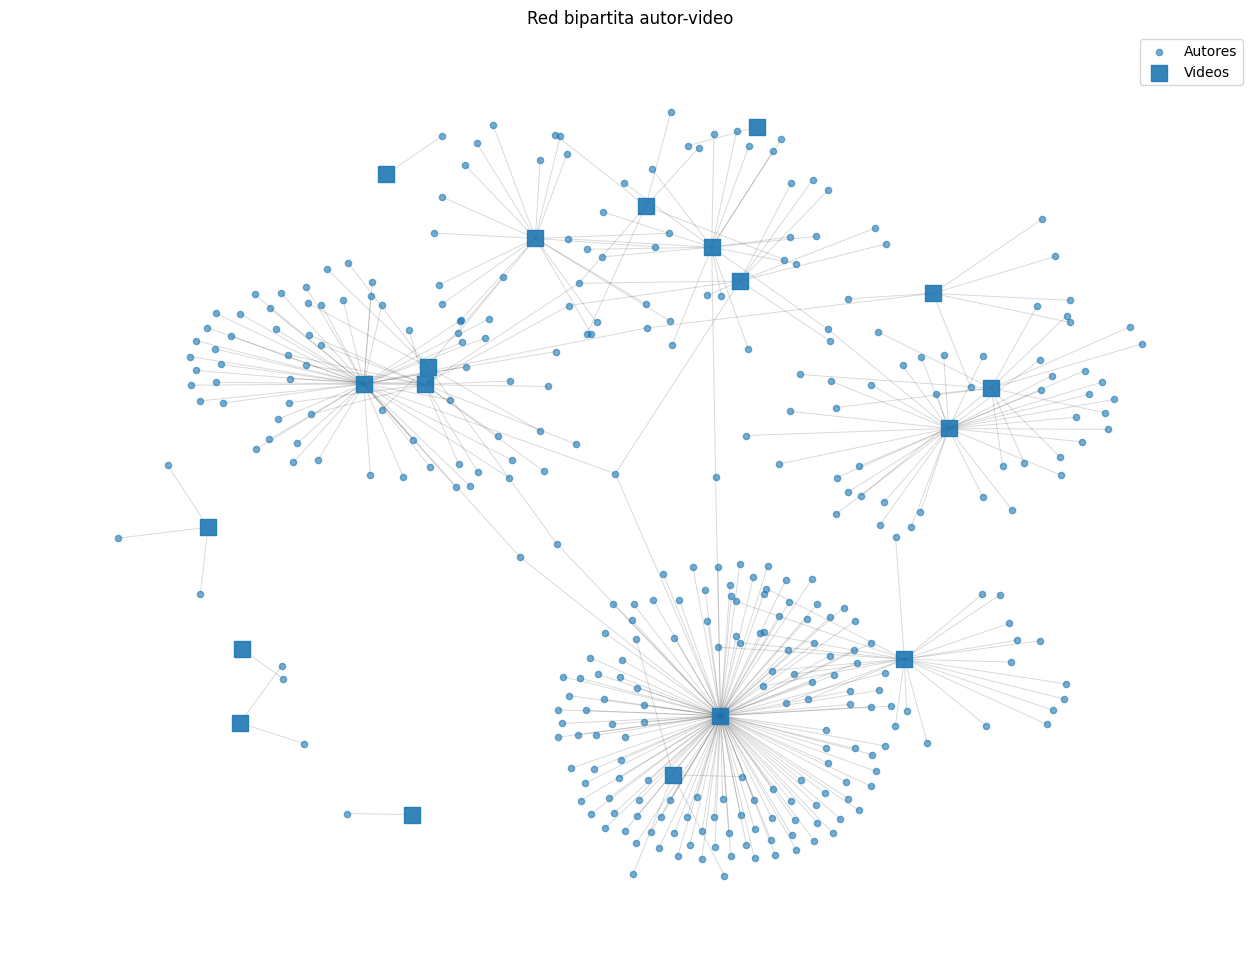

In [170]:
plt.figure(figsize=(16, 12))

pos = nx.spring_layout(
    red,
    seed=42,
    k=0.5,
    iterations=150,
    weight=None
)

# aristas
nx.draw_networkx_edges(
    red,
    pos,
    alpha=0.15,
    width=0.7
)

# autores
nx.draw_networkx_nodes(
    red,
    pos,
    nodelist=autores_red,
    node_size=20,
    node_shape="o",
    alpha=0.6,
    label="Autores"
)

# videos
nx.draw_networkx_nodes(
    red,
    pos,
    nodelist=videos_red,
    node_size=120,
    node_shape="s",
    alpha=0.9,
    label="Videos"
)

plt.title(
    "Red bipartita autor-video"
)

plt.legend()

plt.axis("off")

plt.show()

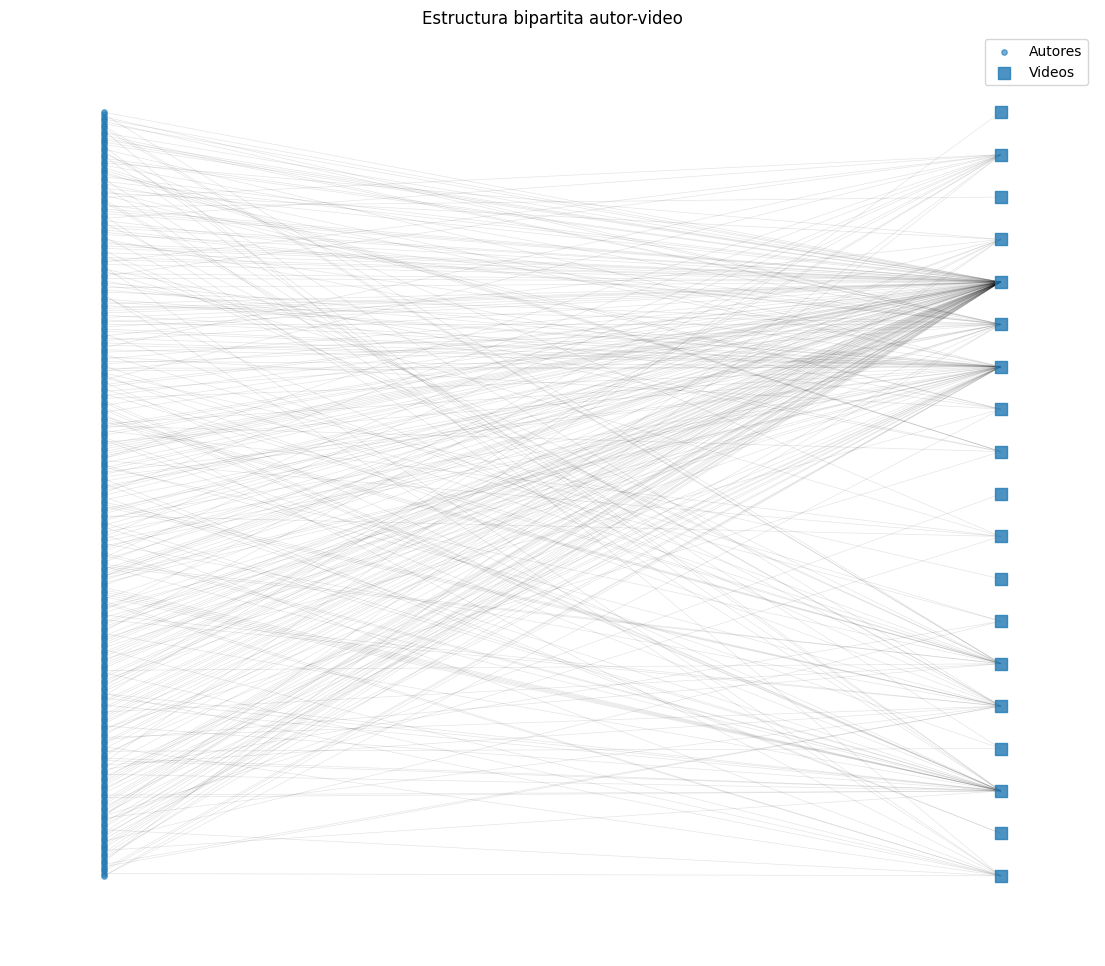

In [171]:
# segunda visualizacion mas bonita
plt.figure(figsize=(14, 12))

pos_bipartita = nx.bipartite_layout(
    red,
    autores_red,
    align="vertical"
)

nx.draw_networkx_edges(
    red,
    pos_bipartita,
    alpha=0.10,
    width=0.5
)

nx.draw_networkx_nodes(
    red,
    pos_bipartita,
    nodelist=autores_red,
    node_size=15,
    node_shape="o",
    alpha=0.6,
    label="Autores"
)

nx.draw_networkx_nodes(
    red,
    pos_bipartita,
    nodelist=videos_red,
    node_size=80,
    node_shape="s",
    alpha=0.8,
    label="Videos"
)

plt.title(
    "Estructura bipartita autor-video"
)

plt.legend()

plt.axis("off")

plt.show()

### 4.5 Interpretación de las aristas

Una arista lo que hace es conectar a un autor con un video cuando existe al menos un comentario de ese autor en dicho video dentro del conjunto de datos analizado.

El peso de la arista representa la cantidad de comentarios publicados por ese autor en el video.

Por lo tanto, la conexión representa únicamente **participación observada**.

No significa que exista amistad, afinidad, aprobación o comunicación directa entre los usuarios.

Tampoco se utiliza `reply_count` para conectar autores, porque esta variable indica cuántas respuestas recibió un comentario, pero no identifica quién realizó esas respuestas

Ya con esto podemos ver que las aristas nos ayudan a entender la participación de los autores en los videos, pero no necesariamente reflejan relaciones directas entre ellos.

In [173]:
# resultados reproducibles derivados de los csv originales 
from pathlib import Path

Path("../output").mkdir(
    exist_ok=True
)

tabla_nodos.to_csv(
    "../output/tabla_nodos.csv",
    index=False
)

tabla_aristas.to_csv(
    "../output/tabla_aristas.csv",
    index=False
)